# Zfp462 figure analysis

In [1]:
here::i_am("thesis/Thesis_figures.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”


In [31]:
args = list()
args$DEGs = file.path(io$basedir, '/results/rna_atac/differential/v2/expression/DEGs_edgeR_pb.txt.gz')
args$meta = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')
args$sce = io$rna.sce

args$outdir = file.path(io$basedir, '/results/thesis/Zfp462/')
dir.create(args$outdir, showWarnings=F, recursive=T)

In [11]:
DEGs = fread(args$DEGs) %>% 
    .[,celltype := opts$celltype_v2_figure[match(celltype, names(opts$celltype_v2_figure))]]

In [12]:
head(DEGs)

gene,logFC,padj_fdr,mean_groupA,mean_groupB,cdr_groupA,cdr_groupB,celltype
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Ftl1,1.029,7.50e-21,7.04,8.09,0.73,0.84,PGC
Tpm1,0.777,1.91e-18,8.57,9.37,0.77,0.91,PGC
Etv2,-1.926,7.29e-18,5.52,3.69,0.40,0.18,PGC
Limch1,0.962,8.96e-17,6.73,7.71,0.44,0.72,PGC
Fst,0.670,3.09e-15,8.08,8.77,0.71,0.77,PGC
Cdkn1c,0.719,3.03e-14,6.98,7.72,0.60,0.84,PGC


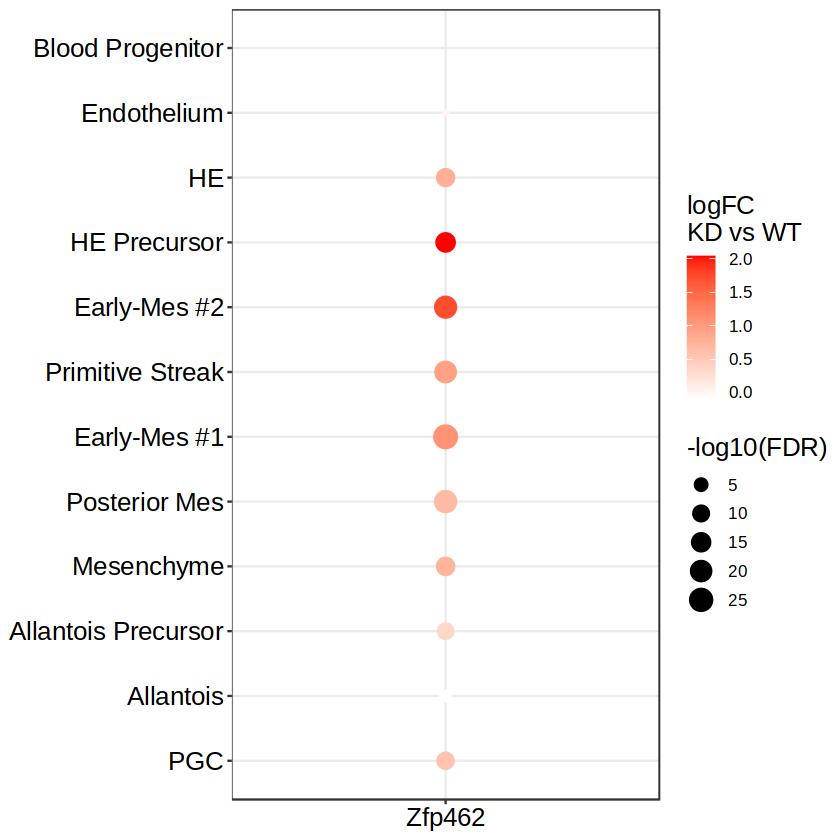

In [30]:
p1 = ggplot(DEGs[gene == 'Zfp462'], aes(gene, celltype, color = logFC, size = -log10(padj_fdr))) + 
    geom_point() + 
    scale_color_gradientn(colours = c('white', 'red'), name = 'logFC \nKD vs WT') + 
    scale_size_continuous(name = '-log10(FDR)') + 
    scale_y_discrete(limits = opts$celltype_v2_figure) + 
    theme_bw() + 
    theme(axis.text = element_text(color = 'black', size = 15),
         axis.title = element_blank(), 
         legend.title = element_text(size = 15),
          legend.text = element_text(size = 10))
p1

ggsave(file.path(args$outdir, 'DiffExpr.pdf'),
       plot = p1,
       width = 100, 
       height = 80, 
       units = "mm")

In [62]:
meta = fread(args$meta)
sce = load_SingleCellExperiment(args$sce, normalise = T, cells = meta$cell)

In [63]:
meta$expr = as.vector(logcounts(sce['Zfp462', meta$cell]))
meta$genotype = factor(ifelse(meta$genotype == 'WT', 'WT', 'Eomes-KD'), levels = c('WT', 'Eomes-KD'))

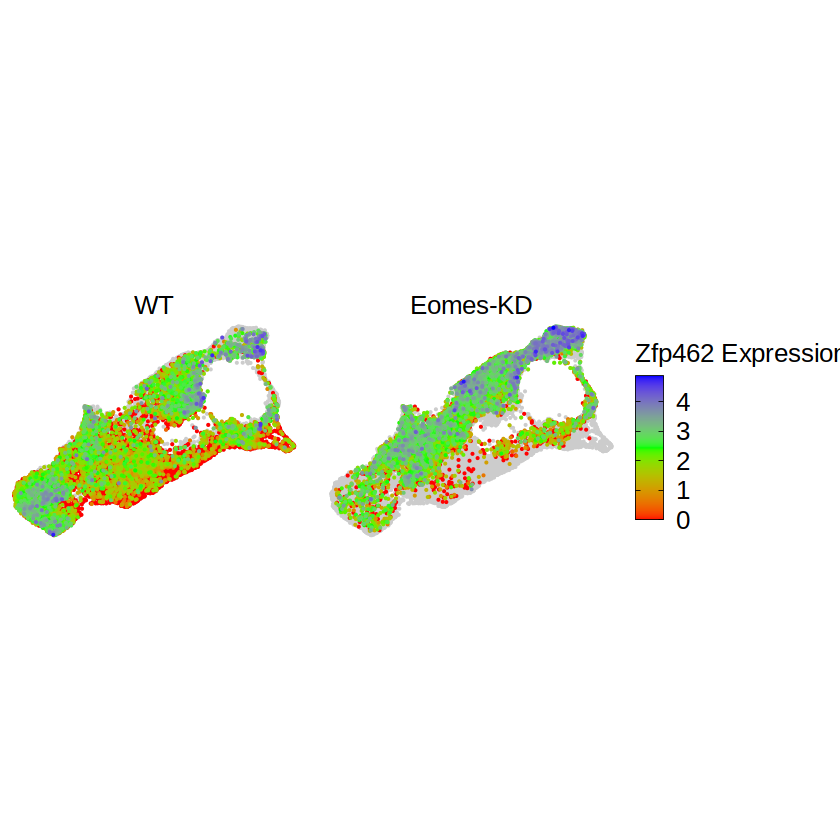

In [69]:
p2 = ggplot(meta[order(expr)], aes(UMAP1, UMAP2, color = expr)) + 
    geom_point(data = copy(meta)[,genotype := 'WT'] , color='grey80', size = 0.1) + 
    geom_point(data = copy(meta)[,genotype := 'Eomes-KD'] , color='grey80', size = 0.1) + 
    geom_point(size = 0.1) + 
    # scale_color_gradientn(colours = c('white', 'grey90', 'darkred'), values = c(0,0.2,1)) + 
    scale_color_gradientn(colors = rainbow(3), name = 'Zfp462 Expression') + 
       guides(
            colour = guide_colourbar(
                # barwidth = 0.5, barheight = 2.5,
                frame.colour = "black", 
                ticks.colour = "black",
                order = 2, 
            )) + 
    facet_wrap(~genotype) + 
    coord_fixed(ratio = 1) +
    theme_void() + 
    theme(strip.text.x = element_text(size = 15), 
         legend.title = element_text(size = 15),
          legend.text = element_text(size = 15)
         ) 

p2

ggsave(file.path(args$outdir, 'UmapExpr.pdf'),
       plot = p2,
       width = 160, 
       height = 130, 
       units = "mm")

In [74]:
library(tradeSeq)

In [70]:
sceGAM = readRDS(file.path(io$basedir, 'results/rna_atac/trajectory/v3/sceGAM.rds'))

In [75]:
yhatSmooth <- predictSmooth(sceGAM, gene = 'Zfp462', nPoints = 100, tidy=TRUE)

In [85]:
head(RNA_filt.dt)

Traj,pseudotime,gene,Expr
<chr>,<dbl>,<chr>,<dbl>
1,2.000817,Zfp462,0.8804343
1,2.081581,Zfp462,0.8453431
1,2.162344,Zfp462,0.8116106
1,2.243108,Zfp462,0.7792939
1,2.323872,Zfp462,0.7484368
1,2.404635,Zfp462,0.7190714


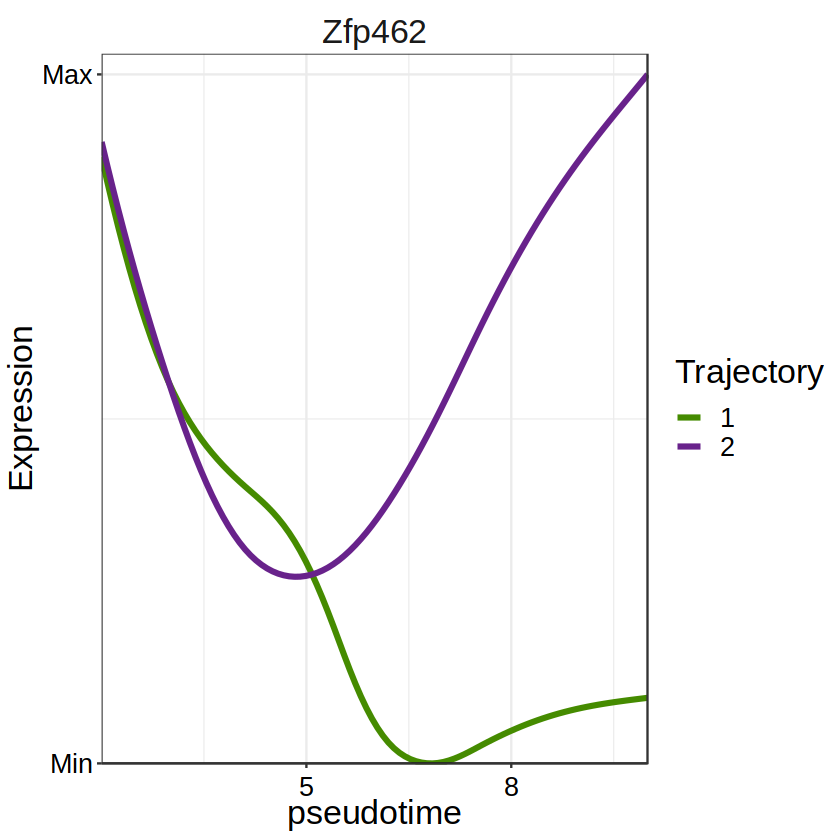

In [108]:
RNA_filt.dt = as.data.table(yhatSmooth) %>% 
        setnames(c('lineage', 'time', 'yhat'), c('Traj', 'pseudotime', 'Expr')) %>%
        .[,Traj:=as.character(Traj)] %>%
        .[, Expr := minmax.normalisation(Expr)]

p3 = ggplot(RNA_filt.dt, aes(pseudotime, Expr, color=Traj)) + 
    #    geom_point(size=0.2, alpha=0.2) +
        geom_line(linewidth = 1.3) + 
        scale_color_manual(values=c('1'='chartreuse4', '2'='darkorchid4'), name='Trajectory') + 
        scale_x_continuous(expand=c(0,0, 0, 0), breaks=c(seq(2, 50, 3))) + 
        scale_y_continuous(expand=c(0,0, 0.03, 0), breaks=c(0,1), labels = c('Min', 'Max'), name = 'Expression') + 
    #    geom_smooth(se = F) +
        geom_hline(yintercept=0) +
        facet_wrap(~gene) + 
        theme_bw() + 
        theme(strip.background = element_blank(),
              strip.text.x = element_text(size = 20),
              text = element_text(size=20),
              axis.text = element_text(color='black'),
              axis.text.x = element_text(angle=0, hjust=0.5, vjust=0),
              axis.text.y = element_text())
return(p3)

ggsave(file.path(args$outdir, 'trajExpr.pdf'),
       plot = p3,
       width = 110, 
       height = 85, 
       units = "mm")